# CIFAR-10 Simple CNN

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

### 1. Load & Preprocess Data


In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

### 2. Data Augmentation


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

### 3. Build CNN Model


In [ ]:
def build_cnn_cifar10():
    model = models.Sequential()

    # -------- Block 1 --------
    model.add(layers.Conv2D(64, 3, padding="same",
                            activation="relu",
                            input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, 3, padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # -------- Block 2 --------
    model.add(layers.Conv2D(128, 3, padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, 3, padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # -------- Block 3 --------
    model.add(layers.Conv2D(256, 3, padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.25))

    # -------- Classifier --------
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation="softmax"))

    return model

model = build_cnn_cifar10()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        1792      
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 64)       256       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        36928     
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 64)       0         
 )                                                               
                                                        

### 4. Compile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### 5. Callbacks


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_cifar10_cnn.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [checkpoint, reduce_lr, early_stop]

### 6. Train

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
782/782 [==============================] - ETA: 0s - loss: 1.6606 - accuracy: 0.4439
Epoch 1: val_loss improved from inf to 1.52851, saving model to best_cifar10_cnn.h5
782/782 [==============================] - 44s 52ms/step - loss: 1.6606 - accuracy: 0.4439 - val_loss: 1.5285 - val_accuracy: 0.5070 - lr: 0.0010
Epoch 2/100
782/782 [==============================] - ETA: 0s - loss: 1.0857 - accuracy: 0.6162
Epoch 2: val_loss improved from 1.52851 to 1.05308, saving model to best_cifar10_cnn.h5
782/782 [==============================] - 39s 50ms/step - loss: 1.0857 - accuracy: 0.6162 - val_loss: 1.0531 - val_accuracy: 0.6440 - lr: 0.0010
Epoch 3/100
781/782 [============================>.] - ETA: 0s - loss: 0.9023 - accuracy: 0.6824
Epoch 3: val_loss improved from 1.05308 to 1.04845, saving model to best_cifar10_cnn.h5
782/782 [==============================] - 39s 50ms/step - loss: 0.9020 - accuracy: 0.6825 - val_loss: 1.0485 - val_accuracy: 0.6653 - lr: 0.0010
Epoch 4/100

### 7. Load Best Model & Evaluate


In [ ]:
best_model = tf.keras.models.load_model("best_cifar10_cnn.h5")
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

print(f"\nBest Model Test Accuracy: {test_acc:.4f}")


Best Model Test Accuracy: 0.8967


### 8. Summary


Test Accuracy: 0.8967

Confusion Matrix:



,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,909,5,18,3,3,0,4,7,35,16
automobile,5,958,0,0,1,0,2,1,2,31
bird,30,2,833,17,32,20,47,11,4,4
cat,8,4,33,738,38,77,61,18,9,14
deer,3,1,17,13,903,7,34,18,4,0
dog,2,2,15,69,26,828,24,24,3,7
frog,4,0,9,7,3,0,972,1,2,2
horse,7,0,10,5,21,9,11,932,1,4
ship,20,10,1,0,2,1,5,2,946,13
truck,11,29,1,2,1,0,0,1,7,948



Per-Class Performance:



,Class,Total,Correct,Incorrect,Accuracy (%)
0,airplane,1000,909,91,90.9
1,automobile,1000,958,42,95.8
2,bird,1000,833,167,83.3
3,cat,1000,738,262,73.8
4,deer,1000,903,97,90.3
5,dog,1000,828,172,82.8
6,frog,1000,972,28,97.2
7,horse,1000,932,68,93.2
8,ship,1000,946,54,94.6
9,truck,1000,948,52,94.8



Classification Report:



,precision,recall,f1-score,support
airplane,0.909910,0.9090,0.909455,1000.0000
automobile,0.947577,0.9580,0.952760,1000.0000
bird,0.889007,0.8330,0.860093,1000.0000
cat,0.864169,0.7380,0.796117,1000.0000
deer,0.876699,0.9030,0.889655,1000.0000
dog,0.878981,0.8280,0.852729,1000.0000
frog,0.837931,0.9720,0.900000,1000.0000
horse,0.918227,0.9320,0.925062,1000.0000
ship,0.933860,0.9460,0.939891,1000.0000
truck,0.912416,0.9480,0.929868,1000.0000


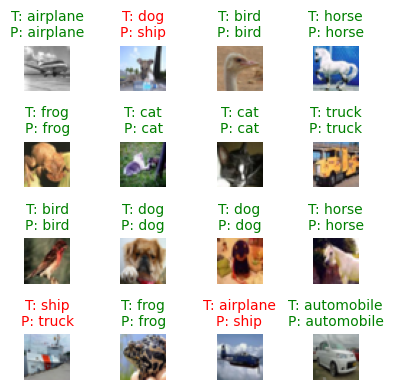

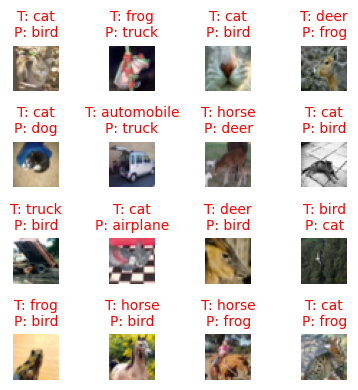

In [ ]:
from model_check import (
    full_classification_report,
    show_predictions_grid,
    show_misclassified_grid
)

cm_df, per_class_df, clf_report_df = full_classification_report(best_model, X_test, y_test)

# نمایش تصادفی
show_predictions_grid(best_model, X_test, y_test, n=4)

# نمایش فقط خطاها
show_misclassified_grid(best_model, X_test, y_test, n=4)